In [5]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt

### 1- Preparation de DataSet 
df = pd.read_csv('social_media_productivity_6000.csv')# cette ligne permet de lire DataSet

# Nettoyage rapide (suppression des lignes avec des valeurs manquantes)
df = df.dropna()

Biais (theta0): 1.78, Coefficient (theta1): 8.82

Biais: 28.76
Coefficients (study_hours, social_media_hours): [ 8.83060319 -6.51580667]

Coefficients (Biais, X, X^2): [5.14698704 6.31740085 0.31093317]



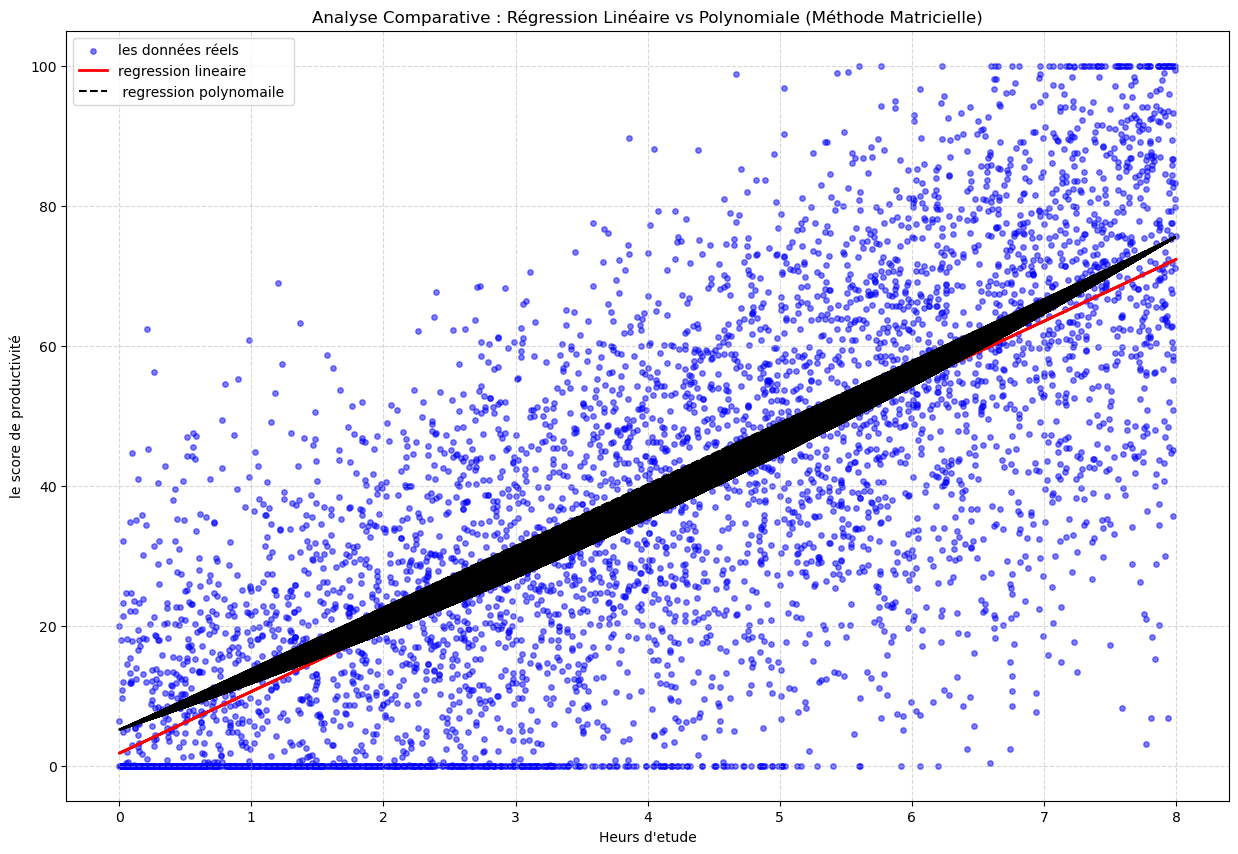

In [29]:
### 2- Modele : represente la relation entre les entrees( features ) et la sortie ( target) 
# Variables : X (indépendante), y (dépendante)
# X_simple :  presente l'impact des heurs d'étude sur la productivité
X_simple = df[['study_hours']]

# X_multiple : presente la combinnaision entre le colonne de study_hours et le colonne de socail_media_hours et sont effet sur le score de productivité
X_multiple = df[['study_hours', 'social_media_hours']]

# y : variable cible ( le score de productivité )
y = df['productivity_score']

### 3- Fonction Cout : Cette fonction résout analytiquement le problème de minimisation des moindres carrés.
## Formule mathématique : Theta = (X^T * X)^-1 * X^T * y

def fit_scratch(X_input, y_target):
    ## ajouter du biais
    # l'equation de regression Y = aX + b , l'ordinateur ne calculerait que la pente a pour ce la on va ajoute une colonne rempli de "1"
    # on transforme l'équation en un produit matriciel simple Y = theta * X 
    # le premier coefficient de theta multiplicateur toujours le "1" , ce qui donnera le b (l'interception).
    X_b = np.c_[np.ones((len(X_input), 1)), X_input]

    ## Calcul des paramètres optimaux (Theta) 
    # .T  : Transposée de la matrice
    # .dot : Produit matriciel
    # np.linalg.inv : Inverse de la matrice
    # Cette ligne unique remplace tout l'entraînement d'un modèle de bibliothèque.
    theta_best = np.linalg.inv(X_b.T.dot(X_b)).dot(X_b.T).dot(y_target)
    
    return theta_best

### 4- Algorithme d'apprentissage

## Regression lineaire ##
theta_simple = fit_scratch(X_simple, y)
print(f"Biais (theta0): {theta_simple[0]:.2f}, Coefficient (theta1): {theta_simple[1]:.2f}\n")

## Regression multiple ( Modele : y = theta0 + theta1*x1 + theta2*x2 ##
# dans ce type de regression , on traite deux variables ( deux colonne d'entrées)
theta_mult = fit_scratch(X_multiple, y)
print(f"Biais: {theta_mult[0]:.2f}")
print(f"Coefficients (study_hours, social_media_hours): {theta_mult[1:]}\n")

## Regression polynomaile ( Modèle : y = theta0 + theta1*x + theta2*x²) ##
# dans ce cas on va utilise un autre featur , le caree de X ( fonction polynomaile de degree 2)
X_poly_manual = np.c_[X_simple, X_simple**2]
theta_poly = fit_scratch(X_poly_manual, y)
print(f"Coefficients (Biais, X, X^2): {theta_poly}\n")

### Visualisation
plt.figure(figsize=(15, 10))
# dessiner le nuage de points initial ( les données reeles )
plt.scatter(X_simple, y, color='blue', alpha=0.5, s=15, label = 'les données réels')
 ### regression lineaire 
y_pred_simple = theta_simple[0] + theta_simple[1]*X_simple
plt.plot(X_simple,y_pred_simple, color='red', linewidth=2 , label = 'regression lineaire')

### regression polynomaile
y_pred_poly = theta_poly[0] + theta_poly[1]*X_simple + theta_poly[2]*(X_simple**2)
plt.plot(X_simple, y_pred_poly, color='black',linestyle ='--' , label = ' regression polynomaile ')

plt.title('Analyse Comparative : Régression Linéaire vs Polynomiale (Méthode Matricielle)')
plt.xlabel('Heurs d\'etude')
plt.ylabel('le score de productivité')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()